### 1. Understand the problem

### 2. Import the libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

### 3.Check the train data

In [2]:
dataset_train=pd.read_csv("/kaggle/input/spaceship-titanic/train.csv")
dataset_train.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [3]:
dataset_test=pd.read_csv("/kaggle/input/spaceship-titanic/test.csv")
dataset_test.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
0,0013_01,Earth,True,G/3/S,TRAPPIST-1e,27.0,False,0.0,0.0,0.0,0.0,0.0,Nelly Carsoning
1,0018_01,Earth,False,F/4/S,TRAPPIST-1e,19.0,False,0.0,9.0,0.0,2823.0,0.0,Lerome Peckers
2,0019_01,Europa,True,C/0/S,55 Cancri e,31.0,False,0.0,0.0,0.0,0.0,0.0,Sabih Unhearfus
3,0021_01,Europa,False,C/1/S,TRAPPIST-1e,38.0,False,0.0,6652.0,0.0,181.0,585.0,Meratz Caltilter
4,0023_01,Earth,False,F/5/S,TRAPPIST-1e,20.0,False,10.0,0.0,635.0,0.0,0.0,Brence Harperez


In [4]:
dataset_train.isnull().sum()

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

In [5]:
dataset_test.isnull().sum()

PassengerId       0
HomePlanet       87
CryoSleep        93
Cabin           100
Destination      92
Age              91
VIP              93
RoomService      82
FoodCourt       106
ShoppingMall     98
Spa             101
VRDeck           80
Name             94
dtype: int64

In [6]:
dataset_train.shape

(8693, 14)

In [7]:
dataset_test.shape

(4277, 13)

### 4.Data Pre-processing

In [8]:
df_train=dataset_train.fillna(method="ffill")#fill the null values

In [9]:
df_test=dataset_test.fillna(method="ffill")#fill the null values

In [10]:
df_train.isnull().sum()

PassengerId     0
HomePlanet      0
CryoSleep       0
Cabin           0
Destination     0
Age             0
VIP             0
RoomService     0
FoodCourt       0
ShoppingMall    0
Spa             0
VRDeck          0
Name            0
Transported     0
dtype: int64

In [11]:
df_test.isnull().sum()

PassengerId     0
HomePlanet      0
CryoSleep       0
Cabin           0
Destination     0
Age             0
VIP             0
RoomService     0
FoodCourt       0
ShoppingMall    0
Spa             0
VRDeck          0
Name            0
dtype: int64

In [12]:
df_train.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8693.000000,8693.000000,8693.000000,8693.000000,8693.000000,8693.000000
mean,28.814448,224.358909,459.524215,171.978834,311.027723,304.271713
std,14.495591,663.194283,1611.321116,598.884988,1135.434090,1148.856635
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,48.000000,77.000000,26.000000,61.000000,44.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


In [13]:
df_test.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,4277.000000,4277.000000,4277.000000,4277.000000,4277.000000,4277.000000
mean,28.640168,218.611176,435.936872,177.172785,302.142623,310.454758
std,14.207990,604.876654,1516.255211,558.320088,1108.490204,1242.862813
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,26.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,37.000000,52.000000,76.000000,34.000000,52.000000,36.000000
max,79.000000,11567.000000,25273.000000,8292.000000,19844.000000,22272.000000


In [14]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8693 non-null   object 
 2   CryoSleep     8693 non-null   bool   
 3   Cabin         8693 non-null   object 
 4   Destination   8693 non-null   object 
 5   Age           8693 non-null   float64
 6   VIP           8693 non-null   bool   
 7   RoomService   8693 non-null   float64
 8   FoodCourt     8693 non-null   float64
 9   ShoppingMall  8693 non-null   float64
 10  Spa           8693 non-null   float64
 11  VRDeck        8693 non-null   float64
 12  Name          8693 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(3), float64(6), object(5)
memory usage: 772.6+ KB


In [15]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8693 non-null   object 
 2   CryoSleep     8693 non-null   bool   
 3   Cabin         8693 non-null   object 
 4   Destination   8693 non-null   object 
 5   Age           8693 non-null   float64
 6   VIP           8693 non-null   bool   
 7   RoomService   8693 non-null   float64
 8   FoodCourt     8693 non-null   float64
 9   ShoppingMall  8693 non-null   float64
 10  Spa           8693 non-null   float64
 11  VRDeck        8693 non-null   float64
 12  Name          8693 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(3), float64(6), object(5)
memory usage: 772.6+ KB


In [16]:
#label Encoding
label_encoder=preprocessing.LabelEncoder()
df_train['CryoSleep_type']=label_encoder.fit_transform(df_train["CryoSleep"])
df_train['VIP_type']=label_encoder.fit_transform(df_train["VIP"])
df_train['Transported_type']=label_encoder.fit_transform(df_train["Transported"])
df_train['HomePlanet_type']=label_encoder.fit_transform(df_train["HomePlanet"])
df_train['Destination_type']=label_encoder.fit_transform(df_train["Destination"])
df_train['Spa_type']=label_encoder.fit_transform(df_train["Spa"])
df_train['FoodCourt_type']=label_encoder.fit_transform(df_train["FoodCourt"])
df_train['RoomService_type']=label_encoder.fit_transform(df_train["RoomService"])

In [17]:
label_encoder=preprocessing.LabelEncoder()
df_test['CryoSleep_type']=label_encoder.fit_transform(df_test["CryoSleep"])
df_test['VIP_type']=label_encoder.fit_transform(df_test["VIP"])
df_test['HomePlanet_type']=label_encoder.fit_transform(df_test["HomePlanet"])
df_test['Destination_type']=label_encoder.fit_transform(df_test["Destination"])
df_test['Spa_type']=label_encoder.fit_transform(df_test["Spa"])
df_test['FoodCourt_type']=label_encoder.fit_transform(df_test["FoodCourt"])
df_test['RoomService_type']=label_encoder.fit_transform(df_test["RoomService"])

In [18]:
#delete the unrequired columns
del df_train['CryoSleep']
del df_train['VIP']
del df_train['Transported']
del df_train['Name']
del df_train['HomePlanet']
del df_train['Cabin']
del df_train['Destination']
del df_train['PassengerId']
del df_train['Spa']
del df_train['FoodCourt']
del df_train['RoomService']

In [19]:
del df_test['CryoSleep']
del df_test['VIP']
del df_test['Name']
del df_test['HomePlanet']
del df_test['Cabin']
del df_test['Destination']
del df_test['PassengerId']
del df_test['Spa']
del df_test['FoodCourt']
del df_test['RoomService']

In [20]:
df_train.head()

,Age,ShoppingMall,VRDeck,CryoSleep_type,VIP_type,Transported_type,HomePlanet_type,Destination_type,Spa_type,FoodCourt_type,RoomService_type
0,39.0,0.0,0.0,0,0,0,1,2,0,0,0
1,24.0,25.0,44.0,0,0,1,0,2,456,9,109
2,58.0,0.0,49.0,0,1,0,1,2,1273,1206,43
3,33.0,371.0,193.0,0,0,0,1,2,1132,806,0
4,16.0,151.0,2.0,0,0,1,0,2,470,69,277


In [21]:
df_test.head()

,Age,ShoppingMall,VRDeck,CryoSleep_type,VIP_type,HomePlanet_type,Destination_type,Spa_type,FoodCourt_type,RoomService_type
0,27.0,0.0,0.0,1,0,0,2,0,0,0
1,19.0,0.0,0.0,0,0,0,2,724,9,0
2,31.0,0.0,0.0,1,0,1,0,0,0,0
3,38.0,0.0,585.0,0,0,1,2,155,843,0
4,20.0,635.0,0.0,0,0,0,2,0,0,10


In [22]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               8693 non-null   float64
 1   ShoppingMall      8693 non-null   float64
 2   VRDeck            8693 non-null   float64
 3   CryoSleep_type    8693 non-null   int64  
 4   VIP_type          8693 non-null   int64  
 5   Transported_type  8693 non-null   int64  
 6   HomePlanet_type   8693 non-null   int64  
 7   Destination_type  8693 non-null   int64  
 8   Spa_type          8693 non-null   int64  
 9   FoodCourt_type    8693 non-null   int64  
 10  RoomService_type  8693 non-null   int64  
dtypes: float64(3), int64(8)
memory usage: 747.2 KB


In [23]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4277 entries, 0 to 4276
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               4277 non-null   float64
 1   ShoppingMall      4277 non-null   float64
 2   VRDeck            4277 non-null   float64
 3   CryoSleep_type    4277 non-null   int64  
 4   VIP_type          4277 non-null   int64  
 5   HomePlanet_type   4277 non-null   int64  
 6   Destination_type  4277 non-null   int64  
 7   Spa_type          4277 non-null   int64  
 8   FoodCourt_type    4277 non-null   int64  
 9   RoomService_type  4277 non-null   int64  
dtypes: float64(3), int64(7)
memory usage: 334.3 KB


In [24]:
df_train.columns

Index(['Age', 'ShoppingMall', 'VRDeck', 'CryoSleep_type', 'VIP_type',
       'Transported_type', 'HomePlanet_type', 'Destination_type', 'Spa_type',
       'FoodCourt_type', 'RoomService_type'],
      dtype='object')

### split the data

In [25]:
#split the data into x and y
x=df_train[['Age','ShoppingMall', 'VRDeck', 'CryoSleep_type', 'VIP_type','HomePlanet_type','Destination_type', 'Spa_type','FoodCourt_type','RoomService_type']]
y=df_train[['Transported_type']]

In [26]:
x

,Age,ShoppingMall,VRDeck,CryoSleep_type,VIP_type,HomePlanet_type,Destination_type,Spa_type,FoodCourt_type,RoomService_type
0,39.0,0.0,0.0,0,0,1,2,0,0,0
1,24.0,25.0,44.0,0,0,0,2,456,9,109
2,58.0,0.0,49.0,0,1,1,2,1273,1206,43
3,33.0,371.0,193.0,0,0,1,2,1132,806,0
4,16.0,151.0,2.0,0,0,0,2,470,69,277
...,...,...,...,...,...,...,...,...,...,...
8688,41.0,0.0,74.0,0,1,1,0,932,1389,0
8689,18.0,0.0,0.0,1,0,0,1,0,0,0
8690,26.0,1872.0,0.0,0,0,0,2,1,0,0
8691,32.0,0.0,3235.0,0,0,1,0,321,739,0


In [27]:
y

,Transported_type
0,0
1,1
2,0
3,0
4,1
...,...
8688,0
8689,0
8690,1
8691,0


In [28]:
#train data send for the training and testing
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3)


In [29]:
#scaled the x (train and test data)
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scaled = scaler.fit_transform(df_train)


x_train_scaled = scaler.fit_transform(x_train) 
x_test_scaled=scaler.transform(x_test)
print("Mean value:",x_train_scaled.mean(axis=0))
print("SD value:",x_train_scaled.std(axis=0))

Mean value: [-3.21116273e-17 -3.26954751e-17 -4.08693439e-18 -1.79533189e-17
 -4.20370394e-17 -5.25462993e-17 -1.12682620e-16 -4.81674410e-17
  7.99871445e-17 -3.79501050e-17]
SD value: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [30]:
df_scaled = pd.DataFrame(scaled,columns=df_train.columns)
df_scaled.head()

,Age,ShoppingMall,VRDeck,CryoSleep_type,VIP_type,Transported_type,HomePlanet_type,Destination_type,Spa_type,FoodCourt_type,RoomService_type
0,0.702706,-0.287182,-0.264863,-0.746543,-0.155020,-1.007274,0.421631,0.630432,-0.464984,-0.474269,-0.467045
1,-0.332151,-0.245435,-0.226562,-0.746543,-0.155020,0.992779,-0.831871,0.630432,1.061263,-0.448853,-0.093057
2,2.013525,-0.287182,-0.222209,-0.746543,6.450794,-1.007274,0.421631,0.630432,3.795788,2.931534,-0.319508
3,0.288763,0.332339,-0.096860,-0.746543,-0.155020,-1.007274,0.421631,0.630432,3.323857,1.801914,-0.467045
4,-0.884075,-0.035032,-0.263122,-0.746543,-0.155020,0.992779,-0.831871,0.630432,1.108121,-0.279410,0.483365


### 6.Model selection and implimentation

In [31]:
from sklearn import tree

In [32]:
clf= tree.DecisionTreeClassifier()
clf= clf.fit(x_train_scaled,y_train)

In [33]:
clf.score(x_test_scaled,y_test)*100 #accuracy

72.20092024539878

In [34]:
predict= clf.predict(x_test_scaled)
print(predict)

[0 0 1 ... 0 0 1]


In [35]:
from sklearn.metrics import mean_squared_error,mean_absolute_error
error = mean_absolute_error(predict,y_test)*100
error#error

27.799079754601223

### 7.EDA

In [36]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,predict)
cm

array([[ 867,  385],
       [ 340, 1016]])

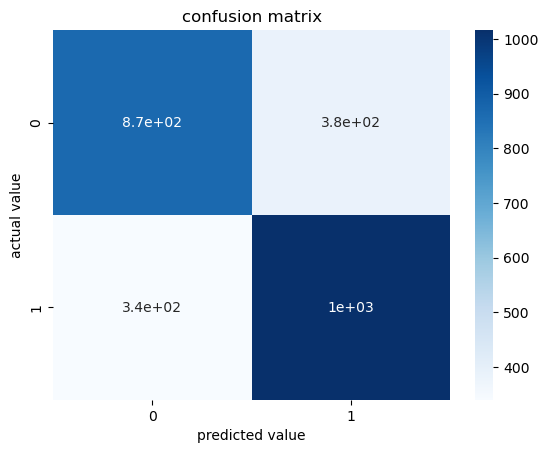

In [37]:
#visulization of confusion matrix
ax=sns.heatmap(cm,annot=True,cmap='Blues')
ax.set_title("confusion matrix")
ax.set_xlabel("predicted value")
ax.set_ylabel("actual value")
plt.show()

In [38]:
df_train['Transported_type'].value_counts()

1    4378
0    4315
Name: Transported_type, dtype: int64

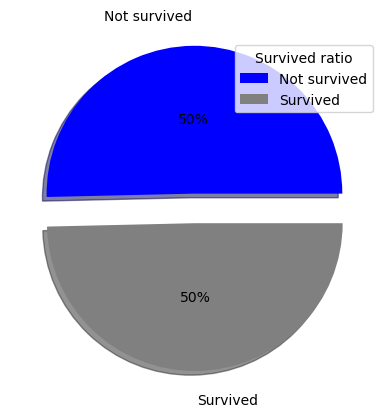

In [39]:
a = df_train['Transported_type'].value_counts()
labels = ['Not survived', 'Survived']
explode = [0.2,0] 
colors = ['blue', 'grey'] 
plt.pie(a, labels=labels, autopct='%1.0f%%', pctdistance=0.5, labeldistance=1.2, explode=explode, colors=colors, shadow = True) 

plt.legend(title = "Survived ratio")
plt.show() 

In [40]:
sample_submission=clf.predict(df_test)
sample_submission

/opt/conda/lib/python3.7/site-packages/sklearn/base.py:444: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  f"X has feature names, but {self.__class__.__name__} was fitted without"


array([0, 1, 0, ..., 0, 0, 0])

In [41]:
pd.DataFrame({
    "Transported" : sample_submission
},columns=["Transported"])

,Transported
0,0
1,1
2,0
3,1
4,1
...,...
4272,0
4273,1
4274,0
4275,0


In [42]:
test1=pd.read_csv("/kaggle/input/spaceship-titanic/test.csv")
test1.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
0,0013_01,Earth,True,G/3/S,TRAPPIST-1e,27.0,False,0.0,0.0,0.0,0.0,0.0,Nelly Carsoning
1,0018_01,Earth,False,F/4/S,TRAPPIST-1e,19.0,False,0.0,9.0,0.0,2823.0,0.0,Lerome Peckers
2,0019_01,Europa,True,C/0/S,55 Cancri e,31.0,False,0.0,0.0,0.0,0.0,0.0,Sabih Unhearfus
3,0021_01,Europa,False,C/1/S,TRAPPIST-1e,38.0,False,0.0,6652.0,0.0,181.0,585.0,Meratz Caltilter
4,0023_01,Earth,False,F/5/S,TRAPPIST-1e,20.0,False,10.0,0.0,635.0,0.0,0.0,Brence Harperez


In [43]:
test2=test1["PassengerId"]
test2

0       0013_01
1       0018_01
2       0019_01
3       0021_01
4       0023_01
         ...   
4272    9266_02
4273    9269_01
4274    9271_01
4275    9273_01
4276    9277_01
Name: PassengerId, Length: 4277, dtype: object

In [44]:
fl = pd.DataFrame({
    "PassengerId":test2.values,
    "Transported" : sample_submission
},columns=["PassengerId","Transported"])
fl

,PassengerId,Transported
0,0013_01,0
1,0018_01,1
2,0019_01,0
3,0021_01,1
4,0023_01,1
...,...,...
4272,9266_02,0
4273,9269_01,1
4274,9271_01,0
4275,9273_01,0


In [45]:
fl.set_index("PassengerId", inplace=True)
fl.to_csv("sample_submission.csv")

In [46]:
pd.read_csv("sample_submission.csv")

,PassengerId,Transported
0,0013_01,0
1,0018_01,1
2,0019_01,0
3,0021_01,1
4,0023_01,1
...,...,...
4272,9266_02,0
4273,9269_01,1
4274,9271_01,0
4275,9273_01,0
